### Load Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### Load Data

In [2]:
# Path to project directory
path_proj = "/Users/angdamian/3-Bioinformatics/machine-learning/bloodmnist-classification"

In [3]:
import medmnist
from medmnist import BloodMNIST
print(medmnist.__version__)

3.0.2


In [4]:
# Download BloodMNIST metadata
from medmnist import INFO
data_flag = "bloodmnist"
info = INFO[data_flag]

In [5]:
# Download BloodMNIST data
train_data = BloodMNIST(split="train", root=f"{path_proj}/data", download=True)
val_data   = BloodMNIST(split="val", root=f"{path_proj}/data", download=True)
test_data  = BloodMNIST(split="test", root=f"{path_proj}/data", download=True)

In [6]:
# Extract observations and labels from BloodMNIST object
X_train = train_data.imgs
y_train = train_data.labels.ravel()

X_val = val_data.imgs
y_val = val_data.labels.ravel()

X_test = test_data.imgs
y_test = test_data.labels.ravel()

In [7]:
# Data shape
print(X_train.shape) # num_samples x height x width x channels
print(y_train.shape) # num_samples x 1

print(X_val.shape) # num_samples x height x width x channels
print(y_val.shape) # num_samples x 1

print(X_test.shape) # num_samples x height x width x channels
print(y_test.shape) # num_samples x 1

(11959, 28, 28, 3)
(11959,)
(1712, 28, 28, 3)
(1712,)
(3421, 28, 28, 3)
(3421,)


In [8]:
# Class labels
print(np.unique(y_train))

[0 1 2 3 4 5 6 7]


In [9]:
# Class labels (full names)
class_names=[
    "Basophil",
    "Eosinophil",
    "Erythroblast",
    "Immature granulocyte",
    "Lymphocyte",
    "Monocyte",
    "Neutrophil",
    "Platelet"
]

### Data Preprocessing

In [10]:
# Flatten
X_train_flat = X_train.reshape(X_train.shape[0], -1)
print(X_train_flat.shape)

X_val_flat = X_val.reshape(X_val.shape[0], -1)
print(X_val_flat.shape)

X_test_flat = X_test.reshape(X_test.shape[0], -1)
print(X_test_flat.shape)

(11959, 2352)
(1712, 2352)
(3421, 2352)


In [11]:
# Scale data
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_flat_scaled = scaler.fit_transform(X_train_flat)
X_val_flat_scaled = scaler.transform(X_val_flat)
X_test_flat_scaled = scaler.transform(X_test_flat)

### Softmax (Multinomial Logistic) Regression

Softmax score for class k: $$s_{k}(x)=(\theta^{(k)})^{T}x$$

Estimated probability for class k: $$\widehat{p}_{k} =\sigma(s(x))_{k}=\frac{exp(s_{k}(x))}{\sum_{j=1}^{K}x_{j}}$$

Softmax cost function (cross-entropy): $$J(\Theta)=-\frac{1}{m}\sum_{i=1}^{m}\sum_{k=1}^{K}y_{k}^{(i)}log(\widehat{p}_{k}^{(i)})$$

#### Baseline Model [Default Parameters]

In [12]:
# Construct a LogisticRegression model
from sklearn.linear_model import LogisticRegression
softmax_regressor = LogisticRegression(
    C=1, 
    l1_ratio=0,
    solver='lbfgs', 
    max_iter=1000, 
    tol=1e-4,
    random_state=42, 
    verbose=1
)

In [13]:
# Train the model
import time
start = time.time()

softmax_regressor.fit(X_train_flat_scaled, y_train)

elapsed = time.time() - start
print(f"Training time: {elapsed:.2f} seconds")

Training time: 19.60 seconds


#### Baseline Evaluation

In [14]:
# Predict for validation data
y_pred_softmax_regressor = softmax_regressor.predict(X_val_flat_scaled)

In [15]:
# Accuracy on validation data
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
acc = accuracy_score(y_val, y_pred_softmax_regressor)
prec = precision_score(y_val, y_pred_softmax_regressor, average='macro')
rec = recall_score(y_val, y_pred_softmax_regressor, average='macro')
f1 = f1_score(y_val, y_pred_softmax_regressor, average='macro')
print(f"Accuracy: {acc}\nPrecision: {prec}\nRecall: {rec}\nF1 score: {f1}")

Accuracy: 0.8078271028037384
Precision: 0.7787606285538138
Recall: 0.7797838676117568
F1 score: 0.7787033347925599


In [16]:
## Accuracy with cross-validation on training data using 5 folds
from sklearn.model_selection import cross_val_score

start = time.time()

# Note: cross_val_score() clones the estimator for each fold, so we do not need to worry about 
# the data leakage from the earlier training of the model on the full training set.
cv_accuracy_softmax_regression_5fold = cross_val_score(
    softmax_regressor, X_train_flat_scaled, y_train, cv=5, scoring='accuracy')
print(f"Cross-validation accuracy using 5-fold CV: {cv_accuracy_softmax_regression_5fold}")

elapsed = time.time() - start
print(f"Cross-validation accuracy scoring time using 5-fold CV: {elapsed:.2f} seconds")

Cross-validation accuracy using 5-fold CV: [0.7826087  0.78971572 0.77759197 0.784699   0.77917189]
Cross-validation accuracy scoring time using 5-fold CV: 64.48 seconds


In [17]:
# Accuracy with cross-validation on training data using 10 folds
start = time.time()

cv_accuracy_softmax_regression_10fold = cross_val_score(
    softmax_regressor, X_train_flat_scaled, y_train, cv=10, scoring='accuracy')
print(f"Cross-validation accuracy using 10-fold CV: {cv_accuracy_softmax_regression_10fold}")

elapsed = time.time() - start
print(f"Cross-validation accuracy scoring time using 10-fold CV: {elapsed:.2f} seconds")

Cross-validation accuracy using 10-fold CV: [0.77591973 0.79264214 0.77842809 0.80518395 0.77675585 0.78511706
 0.78177258 0.80434783 0.76003344 0.77573222]
Cross-validation accuracy scoring time using 10-fold CV: 221.98 seconds


In [18]:
# Evaluating multiple metrics with cross-validation on training data using 10 folds
from sklearn.model_selection import cross_validate
scoring_methods = ["accuracy", "precision_macro", "recall_macro", "f1_macro"]

start = time.time()

cv_scores_softmax_regression_10fold = cross_validate(
    softmax_regressor, X_train_flat_scaled, y_train, cv=10, 
    scoring=scoring_methods, return_train_score=True
)

elapsed = time.time() - start
print(f"Cross-validation multiple scoring time using 10-fold CV: {elapsed:.2f} seconds")

Cross-validation multiple scoring time using 10-fold CV: 259.91 seconds


In [19]:
cv_scores_softmax_regression_10fold_df = pd.DataFrame(cv_scores_softmax_regression_10fold)
print(cv_scores_softmax_regression_10fold_df)

    fit_time  score_time  test_accuracy  train_accuracy  test_precision_macro  \
0  28.156061    0.009827       0.775920        0.990895              0.745207   
1  24.452019    0.008808       0.792642        0.990151              0.768695   
2  24.025339    0.008180       0.778428        0.988851              0.756568   
3  26.289575    0.008273       0.805184        0.990616              0.782869   
4  28.665421    0.129822       0.776756        0.989687              0.747292   
5  21.937573    0.007632       0.785117        0.990059              0.754862   
6  29.223573    0.011378       0.781773        0.990430              0.752194   
7  23.259528    0.009234       0.804348        0.989687              0.784417   
8  24.244924    0.009308       0.760033        0.990988              0.731695   
9  28.970207    0.009989       0.775732        0.990617              0.751781   

   train_precision_macro  test_recall_macro  train_recall_macro  \
0               0.991152           0.7526

In [20]:
cv_scores_train_softmax_regression_10fold_df = cv_scores_softmax_regression_10fold_df.filter(like='train')
print(cv_scores_train_softmax_regression_10fold_df)

   train_accuracy  train_precision_macro  train_recall_macro  train_f1_macro
0        0.990895               0.991152            0.989125        0.990110
1        0.990151               0.990040            0.988231        0.989108
2        0.988851               0.988811            0.986396        0.987558
3        0.990616               0.990276            0.988952        0.989602
4        0.989687               0.989525            0.987544        0.988503
5        0.990059               0.990175            0.988200        0.989167
6        0.990430               0.990102            0.988558        0.989294
7        0.989687               0.989659            0.987789        0.988698
8        0.990988               0.991374            0.988801        0.990053
9        0.990617               0.990525            0.988354        0.989415


In [21]:
cv_scores_train_softmax_regression_10fold_df.mean()

train_accuracy           0.990198
train_precision_macro    0.990164
train_recall_macro       0.988195
train_f1_macro           0.989151
dtype: float64

In [22]:
cv_scores_test_softmax_regression_10fold_df = cv_scores_softmax_regression_10fold_df.filter(like='test')
print(cv_scores_test_softmax_regression_10fold_df)

   test_accuracy  test_precision_macro  test_recall_macro  test_f1_macro
0       0.775920              0.745207           0.752668       0.748656
1       0.792642              0.768695           0.762652       0.764926
2       0.778428              0.756568           0.755904       0.755476
3       0.805184              0.782869           0.784607       0.781974
4       0.776756              0.747292           0.752750       0.749586
5       0.785117              0.754862           0.754386       0.753690
6       0.781773              0.752194           0.763112       0.756970
7       0.804348              0.784417           0.778396       0.780149
8       0.760033              0.731695           0.734946       0.732648
9       0.775732              0.751781           0.757729       0.754552


In [23]:
cv_scores_test_softmax_regression_10fold_df.mean()

test_accuracy           0.783593
test_precision_macro    0.757558
test_recall_macro       0.759715
test_f1_macro           0.757863
dtype: float64

In [24]:
# Cross-validation predictions
from sklearn.model_selection import cross_val_predict

start = time.time()

cv_pred_softmax_regression_10fold = cross_val_predict(
    softmax_regressor, X_train_flat_scaled, y_train, cv=10
)
print(f"Cross-validation predictions using 10-fold CV: {cv_pred_softmax_regression_10fold}")

elapsed = time.time() - start
print(f"Cross-validation predictions scoring time using 10-fold CV: {elapsed:.2f} seconds")

Cross-validation predictions using 10-fold CV: [7 5 6 ... 1 6 3]
Cross-validation predictions scoring time using 10-fold CV: 268.17 seconds


In [25]:
# Per-class CV model evaluation metrics
from sklearn.metrics import classification_report

print(classification_report(y_train, cv_pred_softmax_regression_10fold, target_names=class_names))

                      precision    recall  f1-score   support

            Basophil       0.61      0.60      0.60       852
          Eosinophil       0.92      0.91      0.91      2181
        Erythroblast       0.79      0.82      0.81      1085
Immature granulocyte       0.62      0.62      0.62      2026
          Lymphocyte       0.72      0.74      0.73       849
            Monocyte       0.58      0.58      0.58       993
          Neutrophil       0.84      0.81      0.83      2330
            Platelet       0.98      0.98      0.98      1643

            accuracy                           0.78     11959
           macro avg       0.76      0.76      0.76     11959
        weighted avg       0.78      0.78      0.78     11959



##### Insights
* General trend: The larger the class, the higher the precision, recall and F1-scores.
* Exceptions: Immature granulocyte is one of the largest classes (2,026 images) but has a poor scoring all across.
* Eosinophils and platelets have the best classification results.
* Erythroblasts and neutrophils classifications rank second-place, with lymphocytes close behind.
* Basophils, immature granulocytes and monocytes classification performed particularly poorly.
* These insights are supported by the mean-pixel images from EDA notebook, where basophils, immature granulocytes and monocytes have similar dimensions and colour to one another, whereas eosinophils and platelets look very different from al other cell types.
* The reasonable, but unimpressive accuracy of 78% is explained by the mostly good classification results diminished by the poor performance of large classes like immature granulocytes.
* Weighted scores are slightly higher than the macro scores because it gives proportional weightage to classes, and 3 of the 4 large classes have good classification results.
* The moderate class imbalance where the largest class (neutrophils) is almost three times as numerous as the smallest class (lymphocytes) can make accuracy, which is affected by skewed data, less reliable than precision, recall and F1 scores.

In [26]:
# Confusion matrix
from sklearn.metrics import confusion_matrix

cm_softmax_regression = confusion_matrix(y_train, cv_pred_softmax_regression_10fold)
cm_softmax_regression

array([[ 513,   18,   17,  205,   36,   36,   27,    0],
       [  39, 1983,    2,   18,    8,   21,  107,    3],
       [  10,    3,  895,   30,   78,   13,   38,   18],
       [ 182,   28,   51, 1265,   73,  292,  135,    0],
       [  26,    1,   74,   70,  631,   22,   24,    1],
       [  36,   11,   16,  315,   15,  574,   26,    0],
       [  41,  119,   70,  137,   29,   28, 1897,    9],
       [   0,    1,   12,    0,    5,    0,   12, 1613]])

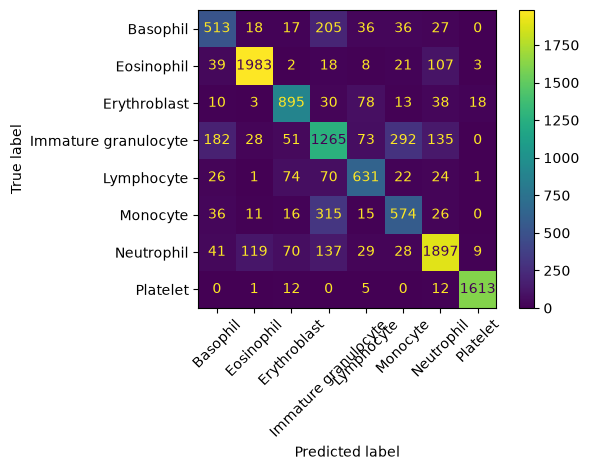

In [27]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(
    y_train, cv_pred_softmax_regression_10fold, display_labels=class_names, xticks_rotation=45)
plt.tight_layout()
plt.show()

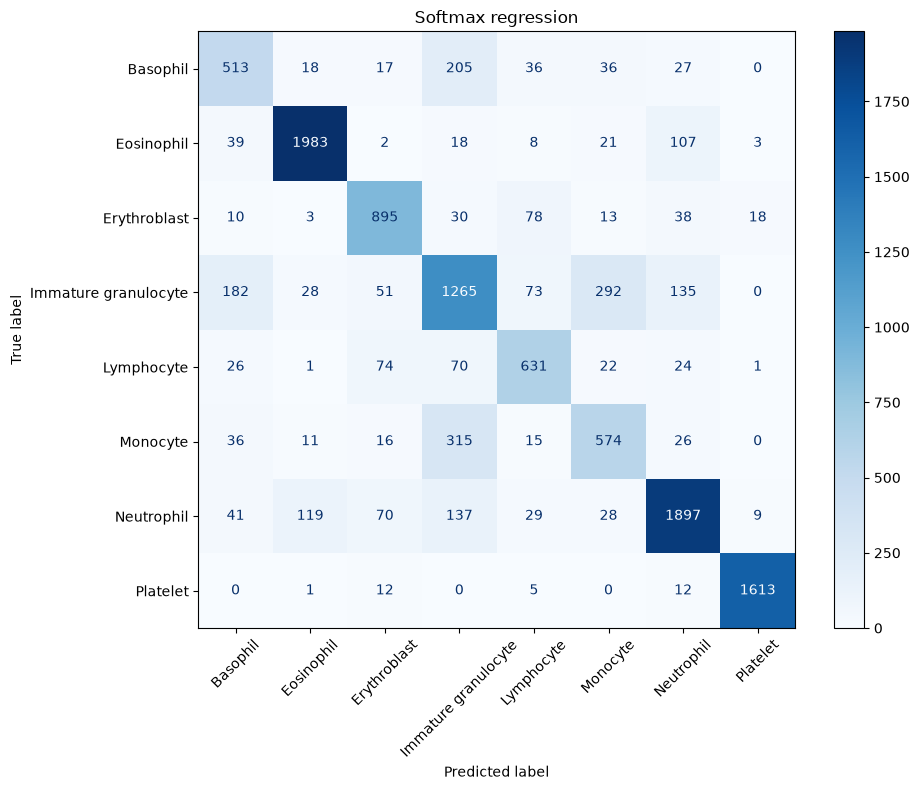

In [28]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_softmax_regression,
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(10, 8))
disp.plot(ax=ax, cmap="Blues", xticks_rotation=45)

plt.title("Softmax regression")
plt.tight_layout()
plt.show()

##### Poor performance of basophils, immature granulocytes and monocytes
* Basophils and monocytes that were incorrectly classified were mostly identified as immature granulocytes.
* Immature granulocytes that were incorrectly classified were mostly identified as basophils, monocytes and (interestingly) neutrophils.